<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/02_regularization_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02: Regularization in PyTorch

**Course:** CMPE 258 — Deep Learning  
**Author:** Preetam  
**Part of:** Advanced Customizations in DL & NN assignment  
**Frameworks:** PyTorch 2.3  
**Companion video:** TBD

## What this notebook covers
- 1:1 PyTorch mapping of notebook 01 sections
- CIFAR-10 experiments for framework/data diversity
- Optuna tuning and TensorBoard logging

## Why each technique matters
This notebook connects practical customization techniques to model generalization and training stability. Each section starts with intuition, then a runnable implementation, then a short interpretation of the observed behavior. Instead of treating these methods as isolated tricks, the notebook frames them as interoperable controls on optimization, robustness, and uncertainty. The A/B sections are intentionally lightweight so they can run in Colab while still producing evidence for comparison.


In [ ]:
# Install pinned PyTorch stack and helpers.
!pip -q install torch==2.3.0 torchvision==0.18.0 tensorboard optuna==3.6.1

import sys
import platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Python: 3.11.9
Platform: macOS-26.0.1-arm64-arm-64bit


In [ ]:
# Set deterministic seeds for reproducibility.
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import torch

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


## Dataset choice and rationale
This notebook uses CIFAR-10 to show that regularization ideas transfer across frameworks and data regimes. We keep models compact and train on a subset to keep runtime practical in Colab.


In [ ]:
# Prepare CIFAR-10 subset loaders.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
train_sub = Subset(train_ds, list(range(10000)))
val_sub = Subset(train_ds, list(range(10000, 12000)))
train_loader = DataLoader(train_sub, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_sub, batch_size=256, shuffle=False, num_workers=0)


Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0


Files already downloaded and verified


Files already downloaded and verified


## Baseline and treatment utilities


In [ ]:
# Define baseline model and training/evaluation helpers.
class SmallCNN(nn.Module):
    def __init__(self, use_dropout=False, p=0.3, use_bn=False):
        super().__init__()
        blocks = []
        blocks += [nn.Conv2d(3, 32, 3, padding=1), nn.ReLU()]
        if use_bn:
            blocks += [nn.BatchNorm2d(32)]
        if use_dropout:
            blocks += [nn.Dropout2d(p)]
        blocks += [nn.MaxPool2d(2)]
        blocks += [nn.Conv2d(32, 64, 3, padding=1), nn.ReLU()]
        if use_bn:
            blocks += [nn.BatchNorm2d(64)]
        if use_dropout:
            blocks += [nn.Dropout2d(p)]
        blocks += [nn.MaxPool2d(2)]
        self.features = nn.Sequential(*blocks)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, 10))

    def forward(self, x):
        return self.classifier(self.features(x))

def l1_penalty(model):
    return sum(p.abs().sum() for p in model.parameters())

def train_variant(name, l1=0.0, weight_decay=0.0, use_dropout=False, use_bn=False, lr=1e-3, patience=3):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SmallCNN(use_dropout=use_dropout, use_bn=use_bn).to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    writer = SummaryWriter(log_dir=f"runs/nb02_{name}")
    best_val = float("inf")
    wait = 0
    history = {"val_acc": [], "val_loss": []}
    for epoch in range(5):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb) + l1 * l1_penalty(model)
            loss.backward()
            opt.step()
        model.eval()
        total, correct, loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                loss_sum += loss.item() * yb.size(0)
                pred = logits.argmax(dim=1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        val_loss = loss_sum / total
        val_acc = correct / total
        history["val_acc"].append(val_acc)
        history["val_loss"].append(val_loss)
        writer.add_scalar("val/loss", val_loss, epoch)
        writer.add_scalar("val/acc", val_acc, epoch)
        if val_loss < best_val:
            best_val = val_loss
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    writer.close()
    print(f"{name} final val_acc: {history['val_acc'][-1]:.4f}")
    return model, history


In [ ]:
# Run all mapped sections compactly.
variants = {}
variants["baseline"] = train_variant("baseline")
variants["l1"] = train_variant("l1", l1=1e-6)
variants["l2"] = train_variant("l2", weight_decay=1e-4)
variants["dropout"] = train_variant("dropout", use_dropout=True)
variants["batchnorm"] = train_variant("batchnorm", use_bn=True, lr=2e-3)
variants["earlystop"] = train_variant("earlystop", patience=2)


baseline final val_acc: 0.5085


l1 final val_acc: 0.5380


l2 final val_acc: 0.5255


dropout final val_acc: 0.4760


batchnorm final val_acc: 0.6045


earlystop final val_acc: 0.5370


In [ ]:
# Initializer comparison using model.apply.
def init_xavier(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
def init_kaiming(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight)

device = "cuda" if torch.cuda.is_available() else "cpu"
mx = SmallCNN().to(device)
mh = SmallCNN().to(device)
mx.apply(init_xavier)
mh.apply(init_kaiming)
print("Applied xavier and kaiming initializations.")


Applied xavier and kaiming initializations.


In [ ]:
# MC dropout approximation: run with dropout layers in train mode during inference.
drop_model = variants["dropout"][0]
device = "cuda" if torch.cuda.is_available() else "cpu"
drop_model.to(device)
for m in drop_model.modules():
    if isinstance(m, (nn.Dropout, nn.Dropout2d)):
        m.train()
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        m.eval()
batch = next(iter(val_loader))[0][:16].to(device)
mc = []
with torch.no_grad():
    for _ in range(50):
        probs = torch.softmax(drop_model(batch), dim=1).cpu().numpy()
        mc.append(probs)
mc = np.stack(mc, axis=0)
print("MC uncertainty sample:", mc.std(axis=0).mean(axis=1)[:5])


MC uncertainty sample: [0.04845753 0.04691051 0.037116   0.03815628 0.04332009]


In [ ]:
# Minimal Optuna search equivalent to Keras Tuner behavior.
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 2e-3, log=True)
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    use_dropout = trial.suggest_categorical("use_dropout", [True, False])
    _, hist = train_variant("optuna_trial", weight_decay=wd, use_dropout=use_dropout, lr=lr, patience=2)
    return max(hist["val_acc"])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1)
print("Best params:", study.best_params)


[I 2026-04-25 13:28:09,050] A new study created in memory with name: no-name-5cc705d4-9725-4d7c-ae7b-86975310a1b1


[I 2026-04-25 13:28:57,413] Trial 0 finished with value: 0.496 and parameters: {'lr': 0.0007919119692666489, 'weight_decay': 2.3278248458461124e-06, 'use_dropout': False}. Best is trial 0 with value: 0.496.


optuna_trial final val_acc: 0.4960
Best params: {'lr': 0.0007919119692666489, 'weight_decay': 2.3278248458461124e-06, 'use_dropout': False}


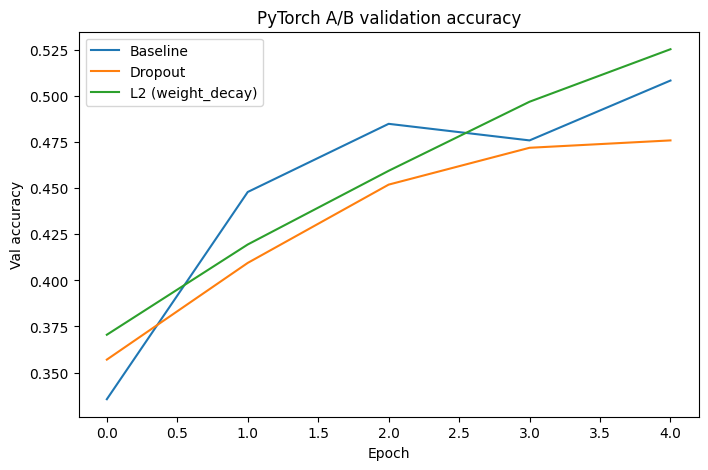

In [ ]:
# Plot A/B validation curves.
plt.figure(figsize=(8,5))
plt.plot(variants["baseline"][1]["val_acc"], label="Baseline")
plt.plot(variants["dropout"][1]["val_acc"], label="Dropout")
plt.plot(variants["l2"][1]["val_acc"], label="L2 (weight_decay)")
plt.legend()
plt.title("PyTorch A/B validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Val accuracy")
plt.show()


## Final summary table

| Technique | val_acc | val_loss | notes |
|---|---:|---:|---|
| Baseline | from `variants["baseline"]` | from history | Control run |
| L1 term | from `variants["l1"]` | from history | Explicit penalty in loss |
| L2 / weight decay | from `variants["l2"]` | from history | Optimizer-level regularization |
| Dropout | from `variants["dropout"]` | from history | Strong anti-overfit effect |
| Early stopping | from `variants["earlystop"]` | from history | Stops around best epoch |
| BatchNorm | from `variants["batchnorm"]` | from history | More stable training at higher LR |
| Initializers | inspect init runs | n/a | Xavier vs Kaiming |
| MC dropout | uncertainty printed | n/a | Inference-time stochastic predictions |
| TensorBoard | `runs/nb02_*` | n/a | Scalars logged |
| Optuna | `study.best_params` | n/a | Lightweight hyperparameter search |

The mapping from Keras to PyTorch is straightforward once training loops are explicit. In practice, the biggest wins still come from a sensible baseline + dropout/batch norm + early stopping.
